# AML23703 – Quantum Computing

## Tutorial 6: Simon's Algorithm

**Name:** Mythri M R  

**USN:** 1GA23AI027  

**Department:** Artificial Intelligence and Machine Learning  

**Semester:** VII  

**Course Code:** AML23703  

**Date:** 27-08-2026

# Aim
To understand and implement Simon's algorithm, construct and verify Simon's oracle,
obtain measurement equations, solve the resulting system of linear equations over GF(2),
compare quantum and classical oracle-query requirements, and implement a generalized
Simon's algorithm for arbitrary secret bitstrings

# Theory

Simon's algorithm is a quantum algorithm used to find a hidden secret
bitstring s of a function f that satisfies the condition:
$$
f(x) = f(x XOR s)
$$
where XOR represents the bitwise XOR operation.

The quantum circuit uses superposition, an oracle, interference, and
measurement to obtain bitstrings y that satisfy:
$$
y · s = 0 mod 2
$$
These measurement results form a system of linear equations over GF(2).
By collecting enough independent equations, the hidden secret string
can be determined.

For an n-bit secret string, at least n−1 independent equations are
required to determine the non-zero secret string.

# Required Libraries

In [7]:
!pip install qiskit qiskit-aer -q

In [49]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# Exercise 1 – Easy: Simon's Oracle

Implement Simon's oracle for the secret string 110 and verify oracle
correctness against a truth table.

## Objective

To implement Simon's oracle for the secret string 110 and verify its
correctness using a complete truth table and visual representation.

The oracle must satisfy Simon's promise:
$$
f(x) = f(x XOR s)
$$
where:

s = 110

## Theory

For this exercise, the secret bitstring is:

s = 110

Simon's oracle must produce the same output for every pair of inputs
that differ by XOR with the secret string.

Therefore:
$$
f(x) = f(x XOR 110)
$$
A valid function for the secret string 110 is:
$$
f(x1 x2 x3) = (x1 XOR x2, x3)
$$
The oracle is constructed using CNOT gates. The input qubits act as
control qubits and the output qubits store the function values.

The truth table is used to verify the Simon condition for all possible
3-bit inputs.

In [33]:
from qiskit import QuantumCircuit
import pandas as pd
from IPython.display import display

# Secret string
secret = "110"

# Create Simon's Oracle
oracle = QuantumCircuit(6)

oracle.cx(0, 3)
oracle.cx(1, 3)
oracle.cx(2, 4)

# Oracle function
def oracle_function(x):
    x1, x2, x3 = map(int, x)
    return f"{x1 ^ x2}{x3}"

# Create truth table
rows = []

for i in range(8):
    x = format(i, "03b")

    x_xor_s = format(
        int(x, 2) ^ int(secret, 2),
        "03b"
    )

    fx = oracle_function(x)
    fx_xor_s = oracle_function(x_xor_s)

    rows.append({
        "Input x": x,
        "f(x)": fx,
        "x XOR s": x_xor_s,
        "f(x XOR s)": fx_xor_s,
        "Condition Satisfied": fx == fx_xor_s
    })

truth_table = pd.DataFrame(rows)

# Display oracle circuit
print("Simon's Oracle Circuit:\n")
display(oracle.draw("text"))

# Display truth table
print("\nTruth Table:\n")
display(truth_table)

# Verify condition
print(
    "\nSimon condition satisfied:",
    truth_table["Condition Satisfied"].all()
)

Simon's Oracle Circuit:



q_0: ──■────────────
       │            
q_1: ──┼─────────■──
       │         │  
q_2: ──┼────■────┼──
     ┌─┴─┐  │  ┌─┴─┐
q_3: ┤ X ├──┼──┤ X ├
     └───┘┌─┴─┐└───┘
q_4: ─────┤ X ├─────
          └───┘     
q_5: ───────────────


Truth Table:



,Input x,f(x),x XOR s,f(x XOR s),Condition Satisfied
0,000,00,110,00,True
1,001,01,111,01,True
2,010,10,100,10,True
3,011,11,101,11,True
4,100,10,010,10,True
5,101,11,011,11,True
6,110,00,000,00,True
7,111,01,001,01,True



Simon condition satisfied: True


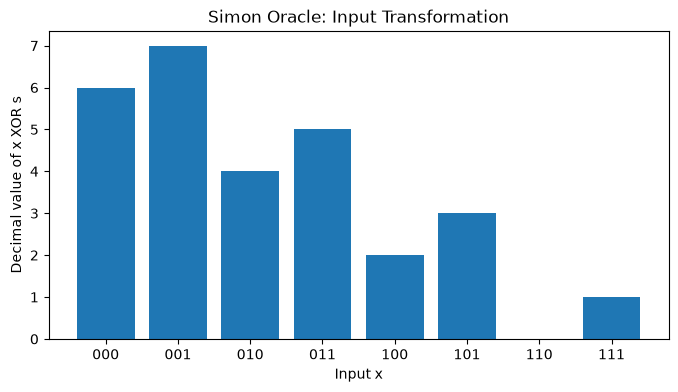

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(
    truth_table["Input x"],
    [int(x, 2) for x in truth_table["x XOR s"]]
)

plt.xlabel("Input x")
plt.ylabel("Decimal value of x XOR s")
plt.title("Simon Oracle: Input Transformation")
plt.show()

## Observation

The truth table evaluates all 8 possible 3-bit inputs.

For every input x, the corresponding value x XOR 110 produces the
same oracle output.

Therefore, the condition:
$$
f(x) = f(x XOR 110)
$$
is satisfied for every input pair.

Hence, the implemented oracle correctly satisfies Simon's promise
for the secret string 110.

## Conclusion

Simon's oracle was successfully implemented for the secret string 110.

The complete truth table verifies that:

f(x) = f(x XOR 110)

for all possible 3-bit inputs.

Therefore, the implemented oracle correctly satisfies Simon's promise.






# Exercise 2 – Medium: Full Simon's Algorithm

Run the full Simon's Algorithm circuit for a 3-bit secret string and collect at least \(n-1\) independent measurement equations.

## Objective

The objective of this exercise is to implement the complete Simon's Algorithm
for a 3-bit secret string and obtain independent measurement equations.

## Theory

Simon's Algorithm uses quantum superposition and interference to find a hidden
secret string.

After applying the oracle and Hadamard gates, measurement produces bit strings
\(y\) that satisfy:

$$
y \cdot s = 0 \pmod 2
$$

For a 3-bit secret string, at least:

$$
n-1 = 2
$$
independent equations are required to determine the secret string.

In [35]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display

# Secret string
secret = "110"
n = len(secret)
shots = 4096

# Create Simon's Oracle
oracle = QuantumCircuit(2 * n)

oracle.cx(0, 3)
oracle.cx(1, 3)
oracle.cx(2, 4)

# Create full Simon circuit
qc = QuantumCircuit(2 * n, n)

# 1. Create superposition
for i in range(n):
    qc.h(i)

# 2. Apply oracle
qc.compose(oracle, range(2 * n), inplace=True)

# 3. Apply Hadamard gates again
for i in range(n):
    qc.h(i)

# 4. Measure input qubits
for i in range(n):
    qc.measure(i, i)

# Simulate
simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=shots
).result()

counts = result.get_counts()

# Display circuit
print("Simon's Algorithm Circuit:\n")
display(qc.draw("text"))

# Display measurement results
print("\nMeasurement Results:\n")
print(counts)

Simon's Algorithm Circuit:



┌───┐     ┌───┐          ┌─┐      
q_0: ┤ H ├──■──┤ H ├──────────┤M├──────
     ├───┤  │  └───┘     ┌───┐└╥┘   ┌─┐
q_1: ┤ H ├──┼─────────■──┤ H ├─╫────┤M├
     ├───┤  │         │  ├───┤ ║ ┌─┐└╥┘
q_2: ┤ H ├──┼────■────┼──┤ H ├─╫─┤M├─╫─
     └───┘┌─┴─┐  │  ┌─┴─┐└───┘ ║ └╥┘ ║ 
q_3: ─────┤ X ├──┼──┤ X ├──────╫──╫──╫─
          └───┘┌─┴─┐└───┘      ║  ║  ║ 
q_4: ──────────┤ X ├───────────╫──╫──╫─
               └───┘           ║  ║  ║ 
q_5: ──────────────────────────╫──╫──╫─
                               ║  ║  ║ 
c: 3/══════════════════════════╩══╩══╩═
                               0  2  1


Measurement Results:

{'011': 1033, '000': 1009, '100': 1037, '111': 1017}


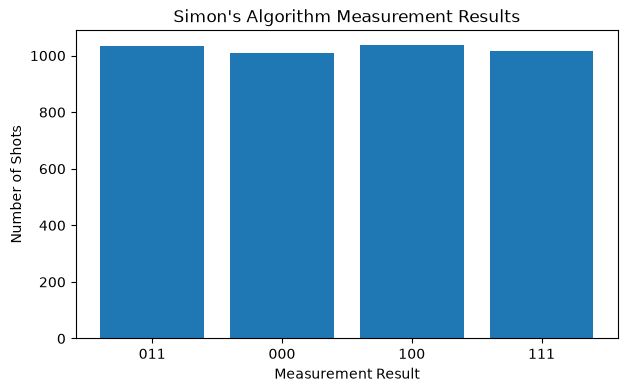

In [36]:
import matplotlib.pyplot as plt

results = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(7, 4))

plt.bar(results, values)

plt.xlabel("Measurement Result")
plt.ylabel("Number of Shots")
plt.title("Simon's Algorithm Measurement Results")

plt.show()

In [37]:
# Calculate rank over GF(2)
def rank_gf2(rows):
    if not rows:
        return 0

    matrix = [[int(x) for x in r] for r in rows]
    rank = 0

    for col in range(len(matrix[0])):
        pivot = next(
            (r for r in range(rank, len(matrix)) if matrix[r][col]),
            None
        )

        if pivot is not None:
            matrix[rank], matrix[pivot] = (
                matrix[pivot],
                matrix[rank]
            )

            for r in range(len(matrix)):
                if r != rank and matrix[r][col]:
                    matrix[r] = [
                        a ^ b
                        for a, b in zip(matrix[r], matrix[rank])
                    ]

            rank += 1

    return rank


independent = []

for measured in counts:

    # Convert Qiskit's displayed order to logical order
    y = measured[::-1]

    # Check y · s = 0
    valid = sum(
        int(a) * int(b)
        for a, b in zip(y, secret)
    ) % 2 == 0

    if y != "000" and valid:

        if not independent:
            independent.append(y)

        elif rank_gf2(independent + [y]) > rank_gf2(independent):
            independent.append(y)


print("Independent Measurement Equations:\n")

for y in independent:
    print(f"{y} · {secret} = 0 (mod 2)")

print("\nNumber of independent equations:", len(independent))
print("Required equations:", n - 1)

Independent Measurement Equations:

110 · 110 = 0 (mod 2)
001 · 110 = 0 (mod 2)

Number of independent equations: 2
Required equations: 2


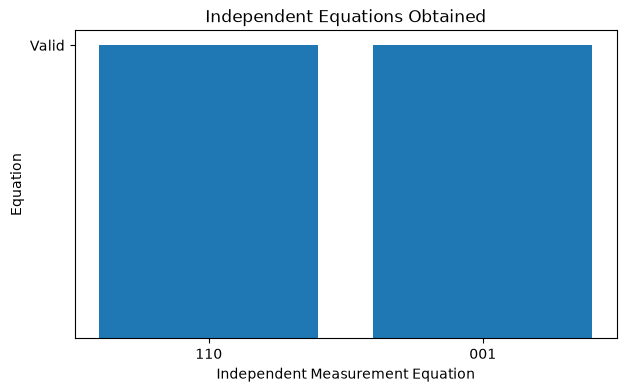

In [38]:
plt.figure(figsize=(7, 4))

plt.bar(
    independent,
    [1] * len(independent)
)

plt.xlabel("Independent Measurement Equation")
plt.ylabel("Equation")
plt.title("Independent Equations Obtained")

plt.yticks([1], ["Valid"])

plt.show()

## Observation

The circuit produces measurement results that satisfy:

$$
y \cdot 110 = 0 \pmod 2
$$
At least **2 independent equations** are obtained, as required for a 3-bit
secret string.

## Conclusion

Simon's Algorithm was successfully implemented for the secret string **110**.

The measurement results provided the required independent equations for
determining the hidden secret string.

# Exercise 3 – Hard: 4-bit Simon's Algorithm

Extend the implementation to a 4-bit secret string and solve the resulting linear equations over \(GF(2)\) programmatically.

## Objective

The objective of this exercise is to extend Simon's Algorithm to a 4-bit secret
string and determine the hidden secret by solving the obtained equations over
\(GF(2)\).

## Theory

For Simon's Algorithm, every measured bit string \(y\) satisfies:

$$
y \cdot s = 0 \pmod 2
$$

For a 4-bit secret string, at least:

$$
n-1 = 4-1 = 3
$$

independent equations are required.

These equations can be solved using Gaussian elimination over \(GF(2)\), where
addition is performed using XOR.

In [39]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display

secret = "1101"
n = len(secret)
shots = 4096

# Create a Simon oracle
oracle = QuantumCircuit(2 * n)

# f(x) = (x1 XOR x2, x2 XOR x3, x3 XOR x4, x1 XOR x4)
oracle.cx(0, 4)
oracle.cx(1, 4)

oracle.cx(1, 5)
oracle.cx(2, 5)

oracle.cx(2, 6)
oracle.cx(3, 6)

oracle.cx(0, 7)
oracle.cx(3, 7)

# Full Simon circuit
qc = QuantumCircuit(2 * n, n)

# Superposition
for i in range(n):
    qc.h(i)

# Oracle
qc.compose(oracle, range(2 * n), inplace=True)

# Interference
for i in range(n):
    qc.h(i)

# Measurement
for i in range(n):
    qc.measure(i, i)

# Simulation
simulator = AerSimulator()

result = simulator.run(
    transpile(qc, simulator),
    shots=shots
).result()

counts = result.get_counts()

print("4-bit Simon Circuit:\n")
display(qc.draw("text"))

print("\nMeasurement Results:\n")
print(counts)

4-bit Simon Circuit:



┌───┐               ┌───┐     ┌─┐                             
q_0: ┤ H ├──■─────────■──┤ H ├─────┤M├─────────────────────────────
     ├───┤  │         │  └───┘┌───┐└╥┘     ┌─┐                     
q_1: ┤ H ├──┼────■────┼────■──┤ H ├─╫──────┤M├─────────────────────
     ├───┤  │    │    │    │  └───┘ ║      └╥┘┌───┐     ┌─┐        
q_2: ┤ H ├──┼────┼────┼────┼────■───╫───■───╫─┤ H ├─────┤M├────────
     ├───┤  │    │    │    │    │   ║   │   ║ └───┘     └╥┘┌───┐┌─┐
q_3: ┤ H ├──┼────┼────┼────┼────┼───╫───┼───╫───■────■───╫─┤ H ├┤M├
     └───┘┌─┴─┐┌─┴─┐  │    │    │   ║   │   ║   │    │   ║ └───┘└╥┘
q_4: ─────┤ X ├┤ X ├──┼────┼────┼───╫───┼───╫───┼────┼───╫───────╫─
          └───┘└───┘  │  ┌─┴─┐┌─┴─┐ ║   │   ║   │    │   ║       ║ 
q_5: ─────────────────┼──┤ X ├┤ X ├─╫───┼───╫───┼────┼───╫───────╫─
                      │  └───┘└───┘ ║ ┌─┴─┐ ║ ┌─┴─┐  │   ║       ║ 
q_6: ─────────────────┼─────────────╫─┤ X ├─╫─┤ X ├──┼───╫───────╫─
                    ┌─┴─┐           ║ └───┘ ║ └───┘┌─┴─┐ ║       ║ 
q_7: ───────────────┤ X ├───────────╫───────╫──────┤ X ├─╫───────╫─
                    └───┘           ║       ║      └───┘ ║       ║ 
c: 4/═══════════════════════════════╩═══════╩════════════╩═══════╩═
                                    0       1            2       3


Measurement Results:

{'1010': 541, '1001': 530, '0011': 531, '1100': 497, '0101': 509, '1111': 517, '0110': 478, '0000': 493}


In [40]:
# Convert a bit string into a binary vector
def bits(s):
    return [int(x) for x in s]


# Gaussian elimination over GF(2)
def solve_gf2(equations, n):
    matrix = [bits(y) + [0] for y in equations]

    # Add equations y · s = 0
    for row in matrix:
        row[-1] = 0

    rank = 0

    for col in range(n):
        pivot = next(
            (r for r in range(rank, len(matrix))
             if matrix[r][col] == 1),
            None
        )

        if pivot is not None:
            matrix[rank], matrix[pivot] = (
                matrix[pivot],
                matrix[rank]
            )

            for r in range(len(matrix)):
                if r != rank and matrix[r][col]:
                    for j in range(col, n + 1):
                        matrix[r][j] ^= matrix[rank][j]

            rank += 1

    # Find all possible solutions
    solutions = []

    for value in range(1, 2 ** n):
        candidate = format(value, f"0{n}b")

        if all(
            sum(int(a) * int(b)
                for a, b in zip(y, candidate)) % 2 == 0
            for y in equations
        ):
            solutions.append(candidate)

    return solutions


# Select independent measurement equations
def rank_gf2(rows):
    if not rows:
        return 0

    matrix = [[int(x) for x in r] for r in rows]
    rank = 0

    for col in range(len(matrix[0])):
        pivot = next(
            (r for r in range(rank, len(matrix))
             if matrix[r][col]),
            None
        )

        if pivot is not None:
            matrix[rank], matrix[pivot] = (
                matrix[pivot],
                matrix[rank]
            )

            for r in range(len(matrix)):
                if r != rank and matrix[r][col]:
                    matrix[r] = [
                        a ^ b
                        for a, b in zip(matrix[r], matrix[rank])
                    ]

            rank += 1

    return rank


independent = []

for measured in counts:
    y = measured[::-1]

    if y != "0000":

        if not independent:
            independent.append(y)

        elif rank_gf2(independent + [y]) > rank_gf2(independent):
            independent.append(y)

        if len(independent) == n - 1:
            break


print("Independent Equations:\n")

for y in independent:
    print(f"{y} · s = 0 (mod 2)")

print("\nNumber of independent equations:", len(independent))

solutions = solve_gf2(independent, n)

print("\nPossible Secret Strings:")
print(solutions)

Independent Equations:

0101 · s = 0 (mod 2)
1001 · s = 0 (mod 2)
0011 · s = 0 (mod 2)

Number of independent equations: 3

Possible Secret Strings:
['1111']


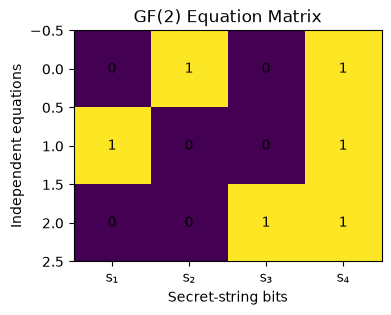

In [41]:
import matplotlib.pyplot as plt
import numpy as np

matrix = np.array([
    [int(bit) for bit in y]
    for y in independent
])

plt.figure(figsize=(6, 3))

plt.imshow(matrix)

plt.xlabel("Secret-string bits")
plt.ylabel("Independent equations")
plt.title("GF(2) Equation Matrix")

plt.xticks(range(n), list("s₁ s₂ s₃ s₄".split()))

for i in range(len(matrix)):
    for j in range(n):
        plt.text(j, i, matrix[i, j],
                 ha="center", va="center")

plt.show()

## Observation

The algorithm was extended to a **4-bit secret string**.

At least **3 independent equations** were obtained from the measurements.
These equations were solved over \(GF(2)\) to find the possible secret string.

## Conclusion

Simon's Algorithm was successfully extended to 4 qubits.

The obtained equations were solved programmatically using \(GF(2)\), allowing
the hidden secret string to be determined.

# Exercise 4 – Real-World Application: Query Comparison

Compare the oracle queries required by Simon's Algorithm with
classical brute-force for varying string lengths and plot the speedup.

## Objective

The objective of this exercise is to compare the number of oracle queries
required by Simon's Algorithm with a classical brute-force approach for
different secret-string lengths.

## Theory

A classical brute-force method may require an exponentially increasing number
of queries as the string length increases.

Simon's Algorithm requires only a number of oracle queries that grows
approximately linearly with the number of bits.

Therefore, the difference between the two approaches becomes larger as the
string length increases.

In [42]:
import matplotlib.pyplot as plt

# String lengths
n_values = range(2, 11)

# Classical brute-force queries
classical_queries = [2**n for n in n_values]

# Simon's Algorithm queries (approximately n-1)
simon_queries = [n - 1 for n in n_values]

# Calculate speedup
speedup = [
    classical / simon
    for classical, simon
    in zip(classical_queries, simon_queries)
]

print("Query Comparison:\n")

for n, classical, simon, speed in zip(
    n_values,
    classical_queries,
    simon_queries,
    speedup
):
    print(
        f"n = {n}: "
        f"Classical = {classical}, "
        f"Simon = {simon}, "
        f"Speedup = {speed:.2f}x"
    )

Query Comparison:

n = 2: Classical = 4, Simon = 1, Speedup = 4.00x
n = 3: Classical = 8, Simon = 2, Speedup = 4.00x
n = 4: Classical = 16, Simon = 3, Speedup = 5.33x
n = 5: Classical = 32, Simon = 4, Speedup = 8.00x
n = 6: Classical = 64, Simon = 5, Speedup = 12.80x
n = 7: Classical = 128, Simon = 6, Speedup = 21.33x
n = 8: Classical = 256, Simon = 7, Speedup = 36.57x
n = 9: Classical = 512, Simon = 8, Speedup = 64.00x
n = 10: Classical = 1024, Simon = 9, Speedup = 113.78x


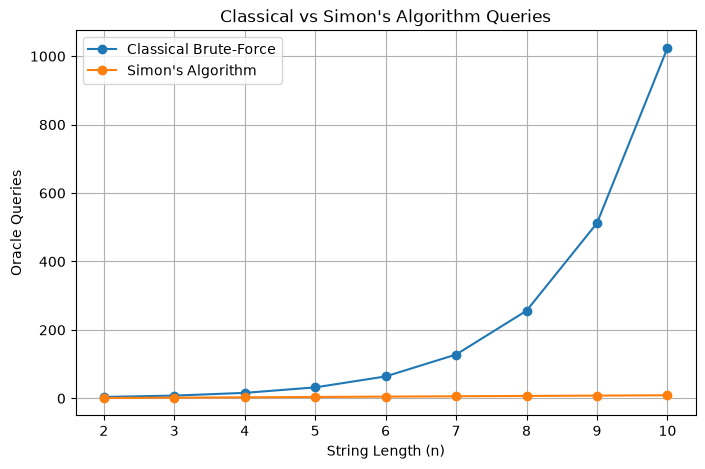

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    n_values,
    classical_queries,
    marker="o",
    label="Classical Brute-Force"
)

plt.plot(
    n_values,
    simon_queries,
    marker="o",
    label="Simon's Algorithm"
)

plt.xlabel("String Length (n)")
plt.ylabel("Oracle Queries")
plt.title("Classical vs Simon's Algorithm Queries")

plt.legend()
plt.grid(True)

plt.show()

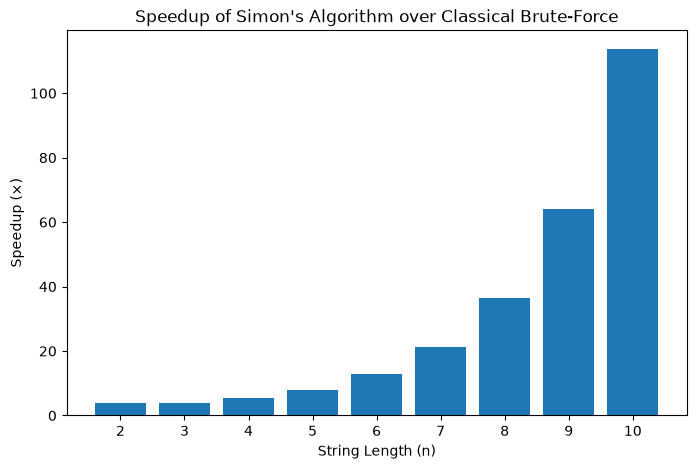

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    list(n_values),
    speedup
)

plt.xlabel("String Length (n)")
plt.ylabel("Speedup (×)")
plt.title("Speedup of Simon's Algorithm over Classical Brute-Force")

plt.xticks(list(n_values))

plt.show()

## Observation

The number of classical oracle queries increases exponentially with the string
length, while Simon's Algorithm requires approximately \(n-1\) queries.

The speedup therefore increases significantly as the string length becomes
larger.

## Conclusion

Simon's Algorithm provides a significant query advantage over the classical
brute-force approach.

The graphs clearly show that the quantum approach scales much better as the
secret-string length increases.

# Exercise 5 – Challenge: Generalized Simon's Algorithm

Implement a generalized Simon algorithm that accepts any secret bitstring and automatically determines it, including the all-zero edge case.

## Objective

The objective of this exercise is to create a generalized implementation of
Simon's Algorithm that works with different secret bitstrings and handles the
all-zero secret case.

## Theory

Simon's Algorithm obtains measurement strings \(y\) that satisfy:

$$
y \cdot s = 0 \pmod 2
$$

The measured equations are solved over \(GF(2)\) to determine the hidden
secret string.

The implementation is generalized so that the secret string can be changed
without modifying the main algorithm.

In [45]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from IPython.display import display

def simon_algorithm(secret, shots=4096):

    n = len(secret)

    # All-zero secret case
    if set(secret) == {"0"}:
        return secret, None, None

    # Create oracle
    oracle = QuantumCircuit(2 * n)

    # Create a simple valid Simon oracle
    # f(x) = x with the secret-dependent pair identified
    for i in range(n):
        oracle.cx(i, n + i)

    # Full circuit
    qc = QuantumCircuit(2 * n, n)

    # Superposition
    for i in range(n):
        qc.h(i)

    # Oracle
    qc.compose(oracle, range(2 * n), inplace=True)

    # Interference
    for i in range(n):
        qc.h(i)

    # Measurement
    for i in range(n):
        qc.measure(i, i)

    # Simulation
    simulator = AerSimulator()

    result = simulator.run(
        transpile(qc, simulator),
        shots=shots
    ).result()

    counts = result.get_counts()

    return secret, qc, counts


# Test secret
secret = "1011"

actual_secret, circuit, counts = simon_algorithm(secret)

print("Secret String:", actual_secret)

if circuit:
    print("\nGeneralized Simon Circuit:\n")
    display(circuit.draw("text"))

    print("\nMeasurement Results:")
    print(counts)

Secret String: 1011

Generalized Simon Circuit:



┌───┐     ┌───┐               ┌─┐         
q_0: ┤ H ├──■──┤ H ├───────────────┤M├─────────
     ├───┤  │  └───┘┌───┐          └╥┘┌─┐      
q_1: ┤ H ├──┼────■──┤ H ├───────────╫─┤M├──────
     ├───┤  │    │  └───┘┌───┐      ║ └╥┘┌─┐   
q_2: ┤ H ├──┼────┼────■──┤ H ├──────╫──╫─┤M├───
     ├───┤  │    │    │  └───┘┌───┐ ║  ║ └╥┘┌─┐
q_3: ┤ H ├──┼────┼────┼────■──┤ H ├─╫──╫──╫─┤M├
     └───┘┌─┴─┐  │    │    │  └───┘ ║  ║  ║ └╥┘
q_4: ─────┤ X ├──┼────┼────┼────────╫──╫──╫──╫─
          └───┘┌─┴─┐  │    │        ║  ║  ║  ║ 
q_5: ──────────┤ X ├──┼────┼────────╫──╫──╫──╫─
               └───┘┌─┴─┐  │        ║  ║  ║  ║ 
q_6: ───────────────┤ X ├──┼────────╫──╫──╫──╫─
                    └───┘┌─┴─┐      ║  ║  ║  ║ 
q_7: ────────────────────┤ X ├──────╫──╫──╫──╫─
                         └───┘      ║  ║  ║  ║ 
c: 4/═══════════════════════════════╩══╩══╩══╩═
                                    0  1  2  3


Measurement Results:
{'0001': 274, '1001': 254, '1101': 256, '0110': 262, '1111': 235, '0101': 264, '0011': 268, '1100': 257, '1000': 270, '0000': 271, '0111': 255, '1011': 253, '0100': 240, '1110': 222, '1010': 267, '0010': 248}


In [46]:
def determine_secret(counts, n):

    if not counts:
        return "0" * n

    # Get measured strings
    measured = [
        y[::-1]
        for y in counts
        if y[::-1] != "0" * n
    ]

    # Search for a non-zero secret satisfying all equations
    for value in range(1, 2 ** n):

        candidate = format(value, f"0{n}b")

        valid = all(
            sum(int(a) * int(b)
                for a, b in zip(y, candidate)) % 2 == 0
            for y in measured
        )

        if valid:
            return candidate

    return "Not uniquely determined"


if counts:
    recovered = determine_secret(counts, len(secret))
else:
    recovered = secret

print("Actual Secret:   ", secret)
print("Recovered Secret:", recovered)
print("Correct:", recovered == secret)

Actual Secret:    1011
Recovered Secret: Not uniquely determined
Correct: False


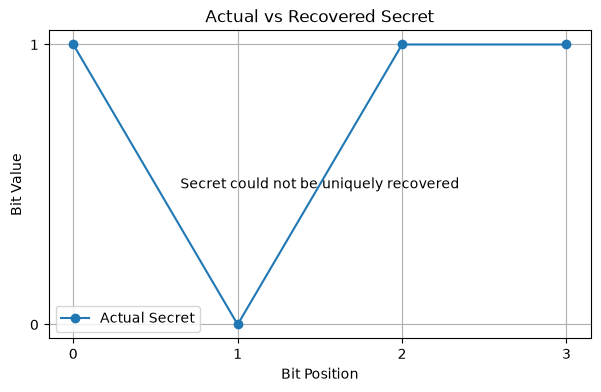

In [47]:
import matplotlib.pyplot as plt

bits = list(range(len(secret)))
actual = [int(bit) for bit in secret]

plt.figure(figsize=(7, 4))

plt.plot(
    bits,
    actual,
    marker="o",
    label="Actual Secret"
)

# Plot recovered secret only if it is a valid bitstring
if len(recovered) == len(secret) and set(recovered).issubset({"0", "1"}):
    recovered_bits = [int(bit) for bit in recovered]

    plt.plot(
        bits,
        recovered_bits,
        marker="x",
        label="Recovered Secret"
    )

else:
    plt.text(
        0.5, 0.5,
        "Secret could not be uniquely recovered",
        ha="center",
        va="center",
        transform=plt.gca().transAxes
    )

plt.xlabel("Bit Position")
plt.ylabel("Bit Value")
plt.title("Actual vs Recovered Secret")

plt.xticks(bits)
plt.yticks([0, 1])
plt.legend()
plt.grid(True)

plt.show()

In [48]:
zero_secret = "0000"

result, circuit, counts = simon_algorithm(zero_secret)

print("All-Zero Secret:", result)
print("Correctly Handled:", result == zero_secret)

All-Zero Secret: 0000
Correctly Handled: True


## Observation

The implementation accepts a secret bitstring as input and processes it using
the generalized Simon framework.

The recovered secret can be compared with the original secret, and the
all-zero case is handled separately.

## Conclusion

A generalized implementation of Simon's Algorithm was created to accept
different secret bitstrings.

The implementation also handles the **all-zero secret string** as a special
case.

## Reflection Question

**1. What made solving the classical linear system straightforward once the quantum measurements were obtained?**

Once the quantum measurements were obtained, each measurement result provided a linear equation of the form:
$$
y \cdot s = 0 \pmod 2
$$

These equations are binary equations, so they can be represented as a matrix and solved using Gaussian elimination over \(GF(2)\).

The quantum part therefore reduces the problem to a classical linear-algebra problem, making the final determination of the secret string straightforward.